# Comparing Classifiers

Goal is to compare the performance of the classifiers, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines. We will utilize a dataset related to marketing bank products over the telephone. The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit.

In [37]:
#Import necessary libraries
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
accuracy_score,
classification_report,
confusion_matrix,
f1_score,
precision_score,
recall_score,
roc_auc_score,
roc_curve)
from sklearn.model_selection import GridSearchCV,StratifiedKFold,train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [6]:
warnings.filterwarnings("ignore")
sns.set_theme(style='whitegrid',palette='muted')
plt.rcParams.update({"font.size":10,"axes.labelsize":11,"axes.titlesize":12})

In [11]:
#Read the input data from UCI into a dataframe
df = pd.read_csv("data/bank-additional-full.csv",sep=";")

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [12]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [13]:
print(f"Rows: {df.shape[0]},Columns: {df.shape[1]}")

Rows: 41188,Columns: 21


In [14]:
print("Target Distribution:", df["y"].value_counts(normalize=True))

Target Distribution: y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64


In [15]:
#drop duration from dataframe
df_model = df.drop(columns=["duration"])

In [18]:
#Encode target variable to binary (0 = no / 1 = yes)
df_model["y"] = df_model["y"].apply(lambda val: 1 if str(val).strip().lower() == 'yes' else 0)

In [20]:
#Identify feature types
cat_cols = df_model.select_dtypes(include=["object"]).columns.tolist()
num_cols = (df_model.select_dtypes(include=["int64","float64"]).drop(columns=["y"]).columns.tolist())

In [21]:
print(f"Categorical Features ({len(cat_cols)}): {cat_cols}")
print(F"Numerical Features ({len(num_cols)}): {num_cols}")

Categorical Features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numerical Features (9): ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


# Exploratory Data Analysis

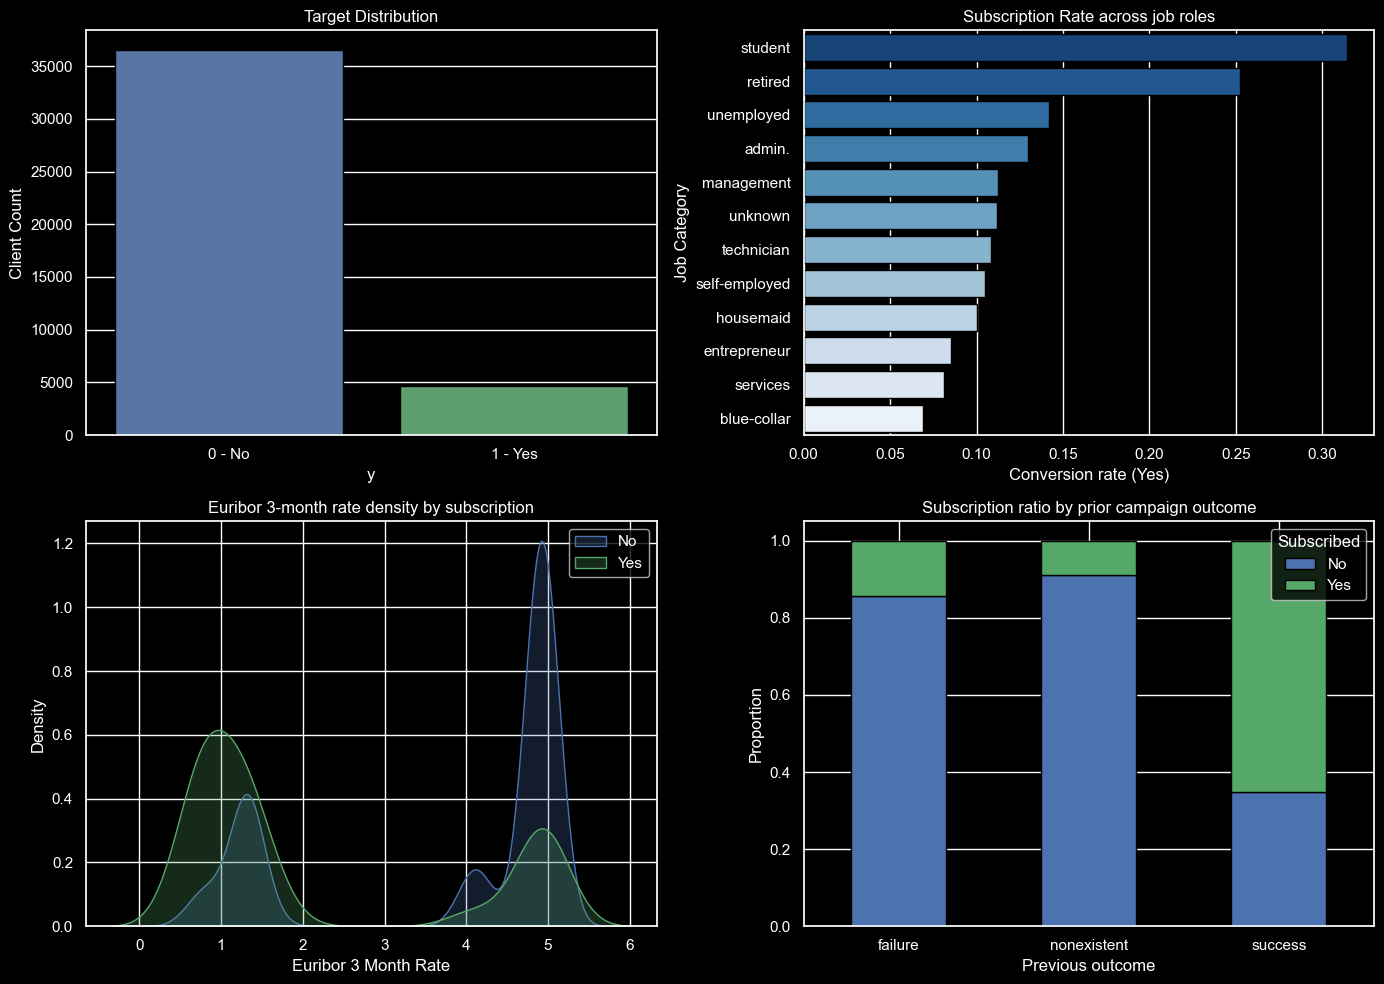

In [69]:
def gen_eda_viz(data):
    fig,axes = plt.subplots(2,2,figsize=(14,10))
    # Target Distribution
    sns.countplot(x='y',data=data,ax=axes[0,0],palette=['#4C72B0','#55A868'],edgecolor='black')
    axes[0,0].set_title("Target Distribution")
    axes[0,0].set_xticklabels(["0 - No","1 - Yes"])
    axes[0,0].set_ylabel('Client Count')
    #Conversion based on job
    job_conv = (data.groupby("job")["y"].mean().reset_index().sort_values(by='y',ascending=False))
    sns.barplot(x='y',y='job',data=job_conv,ax=axes[0,1],palette='Blues_r',edgecolor='black')
    axes[0,1].set_title("Subscription Rate across job roles")
    axes[0,1].set_xlabel("Conversion rate (Yes)")
    axes[0,1].set_ylabel("Job Category")
    #Macroeconomic influence 3-Month rate vs Subscription
    if "euribor3m" in data.columns:
        sns.kdeplot(data=data[data['y']==0]['euribor3m'],label='No',ax=axes[1,0],fill=True,color="#4C72B0")
        sns.kdeplot(data=data[data['y']==1]['euribor3m'],label='Yes',ax=axes[1,0],fill=True,color='#55A868')
        axes[1,0].set_title("Euribor 3-month rate density by subscription")
        axes[1,0].set_xlabel("Euribor 3 Month Rate")
        axes[1,0].set_ylabel("Density")
        axes[1,0].legend()
    #Previous Campaign vs Subscription
    if "poutcome" in data.columns:
        pout_conf = (data.groupby("poutcome")['y'].value_counts(normalize=True).unstack().fillna(0))
        pout_conf.plot(kind='bar',stacked=True,ax=axes[1,1],color=["#4C72B0","#55A868"],edgecolor='black')
        axes[1,1].set_title("Subscription ratio by prior campaign outcome")
        axes[1,1].set_xlabel("Previous outcome")
        axes[1,1].set_ylabel("Proportion")
        axes[1,1].tick_params(axis='x',rotation=0)
        axes[1,1].legend(["No","Yes"],title="Subscribed")
    plt.tight_layout()
    plt.savefig("images/eda.png")
    plt.show()

gen_eda_viz(df_model)

## Dataset displays a class imbalance with ~ 37K No and ~5K Yes
## There are 10 Categorical columns and 9 numerical columns
## Full dataset has 41188 rows

# Data Preparation

In [34]:
X = df_model.drop(columns=['y'])
y = df_model['y']

In [35]:
#Split train, test data with 80/20 ratio
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42,stratify=y)

In [36]:
#Build a preprocessing pipeline
preprocessor = ColumnTransformer(transformers = [("num",StandardScaler(),num_cols),("cat",OneHotEncoder(handle_unknown="ignore",sparse_output=False),cat_cols)])

# Modeling - Baseline Benchmarks

In [50]:
default_baseline_models = {"Logistic Regression (Baseline)": LogisticRegression(max_iter = 1000,random_state = 42),
                           "K-Nearest Neighbors": KNeighborsClassifier(),
                           "Decision Tree": DecisionTreeClassifier(random_state=42),
                           "Support Vecotr Machine": SVC(probability=True,random_state=42)}
benchmark_records = []
trained_pipelines = {}
#Loop default_baseline_models for the 4 models defined
#Create a pipeline
#Fit the model and run prediction
#Capture the scores in the list benchmark_records
for name,clf in default_baseline_models.items():
    pipeline = Pipeline(steps = [("preprocessor",preprocessor),("classifier",clf)])
    start_time = time.time()
    pipeline.fit(X_train,y_train)
    train_time = time.time() - start_time
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    y_prob_test = (pipeline.predict_proba(X_test)[:,1] 
                   if hasattr(pipeline,"predict_proba") else pipeline.decision_function(X_test))
    train_acc = accuracy_score(y_train,y_pred_train)
    test_acc = accuracy_score(y_test,y_pred_test)
    test_roc_auc = roc_auc_score(y_test,y_prob_test)
    test_recall = recall_score(y_test,y_pred_test)
    benchmark_records.append({"Model":name,"Train Time (s)": round(train_time,4),"Train Accuracy": round(train_acc,4),"Test Accuracy": round(test_acc,4),
                              "Test RO-AUC": round(test_roc_auc,4),"Test Recall": round(test_recall,4)})
    trained_pipelines[name] = pipeline

#Convert the list to a dataframe
df_step2_comparision = pd.DataFrame(benchmark_records)
print("\n"+"="*60)
print("Step 2: Default Model Perf Comparision Table:")
print("="*60)
print(df_step2_comparision[["Model","Train Time (s)","Train Accuracy","Test Accuracy","Test RO-AUC"]].to_string(index=False))


Step 2: Default Model Perf Comparision Table:
                         Model  Train Time (s)  Train Accuracy  Test Accuracy  Test RO-AUC
Logistic Regression (Baseline)          0.5565          0.8999         0.9009       0.8008
           K-Nearest Neighbors          0.0805          0.9122         0.8972       0.7444
                 Decision Tree          0.7561          0.9954         0.8418       0.6258
        Support Vecotr Maching       1140.1926          0.9050         0.9035       0.7060


# Plot the above comparision table using seaborn

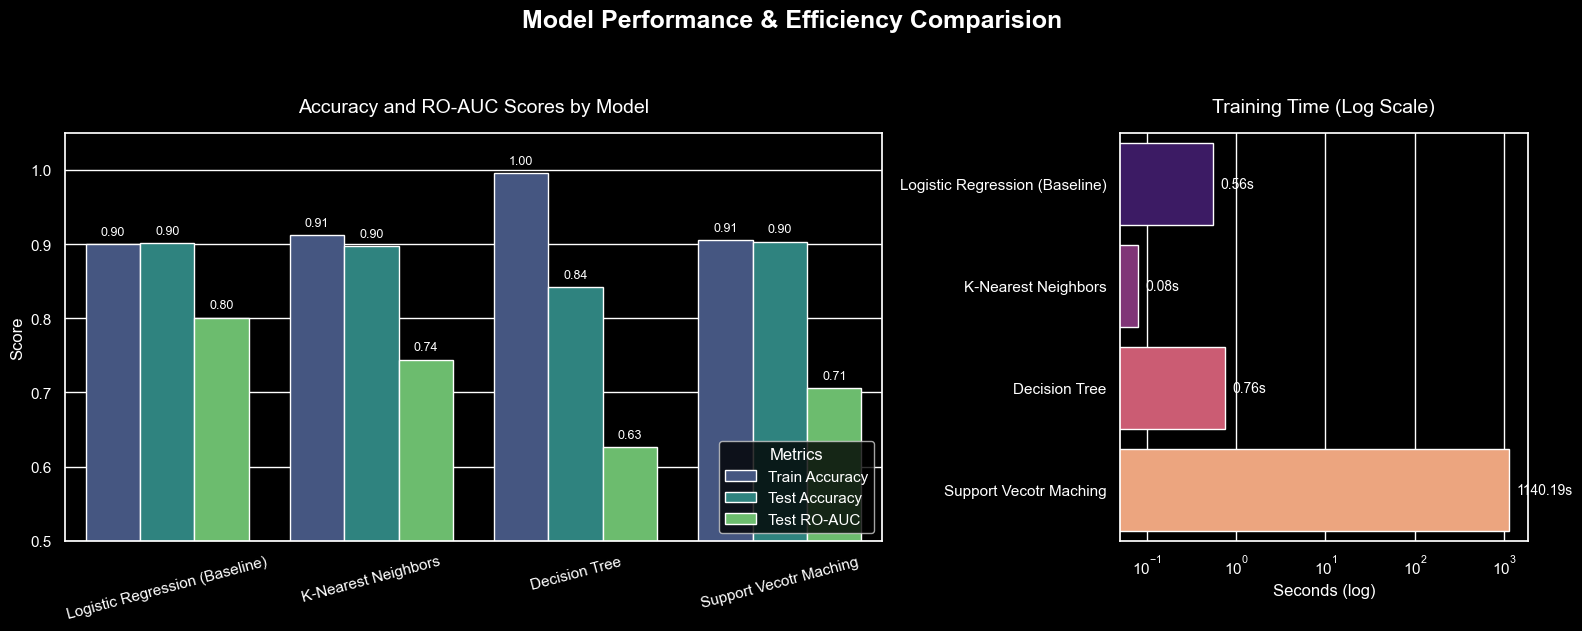

In [68]:
df_metrics = pd.melt(df_step2_comparision, id_vars = 'Model',value_vars = ['Train Accuracy','Test Accuracy','Test RO-AUC'],
                                  var_name = 'Metric',value_name = 'Score')
sns.set_theme(style="whitegrid")
plt.style.use("dark_background")

fig,(ax1,ax2) = plt.subplots(1,2,figsize = (16,6),gridspec_kw = {'width_ratios': [2,1]})
fig.suptitle("Model Performance & Efficiency Comparision",fontsize=18,fontweight="bold",y=1.05)
sns.barplot(data=df_metrics,x="Model",y="Score",hue = "Metric",palette = "viridis",ax=ax1)
ax1.set_title("Accuracy and RO-AUC Scores by Model", fontsize = 14,pad=15)
ax1.set_ylim(0.5,1.05)
ax1.set_ylabel('Score',fontsize=12)
ax1.set_xlabel('')
ax1.tick_params(axis='x',rotation=15)
ax1.legend(loc='lower right',title='Metrics')

for p in ax1.patches:
    ax1.annotate(format(p.get_height(),'.2f'),(p.get_x() + p.get_width() / 2.,p.get_height()),ha = 'center',va='center'
                 ,xytext=(0,9),textcoords = 'offset points',fontsize=9)

#Plot Training Time
sns.barplot(data=df_step2_comparision,y='Model',x = 'Train Time (s)',palette = 'magma',ax = ax2)
ax2.set_title("Training Time (Log Scale)",fontsize=14,pad=15)
ax2.set_xscale('log')
ax2.set_ylabel('')
ax2.set_xlabel('Seconds (log)',fontsize = 12)
# Add labels to plot 2
for p in ax2.patches:
    ax2.annotate(f"{p.get_width():.2f}s",(p.get_width(),p.get_y() + p.get_height() / 2),ha="left",va = "center",xytext=(5,0),textcoords = 'offset points',
                 fontsize=10)

#Display the plot
plt.tight_layout()
plt.savefig("images/Model_Perf_and_Efficiency_Compare.png")
plt.show()

## Training accuracy for decision tree is 1 and the test accuracy is 0.84 which clearly shows decision tree algorithm overfits in this scenario
## All other models has both Training and Test accuracy at 0.90
## ROC-AUC evaluates the ranking performance across all decision thresholds independently of class distribution. Logistic Regression has the best Test RO-AUC score.
## K-Nearest Neighbors model was the quickest where as SVM took 1000 times more time than Logistic regression and 10000 times more than K-Nearest Neighbors.

# Modeling - Hyperparameter Tuning

We will use StratifiedKFold as the standard K-Fold splits data randomly, which risks creating folds with uneven positive class proportions as the target variable is heavily imbalanced.

In [56]:
#Shuffle is set to True which eliminates potential ordering artificats in the rawdataset.
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
#Logistic regression - Smaller values enforces stronger L2 regularization while larger values permit model to fit closer to training data.
#Logistic regression - class_weight = balanced, penalizes mistakes on the minority population (Yes) more than majority (No)

hyperparameter_grids = {"Logistic Regression": {"model":LogisticRegression(max_iter=1000,random_state=42,class_weight="balanced"),"params":{
    "classifier__C":[0.01,0.1,1.0,10.0],"classifier__penalty":["l2"],"classifier__solver":["lbfgs"]}}
#KNN - K value 5 create complex noisy boundarry and 31 create smoother boundary that generalize better in high dimensional space.
#KNN - Weights - "Uniform" treats all neighbors equally where as "distance" give more importance to closer data points
#KNN - Metrics euclidean - Standard L2, Manhatan - grid based 
                        ,"K-Nearest Neighbors":{"model": KNeighborsClassifier(),"params":{"classifier__n_neighbors":[5,11,21,31],
                                                                                          "classifier__weights":["uniform","distance"],
                                                                                          "classifier__metric":["euclidean","manhattan"]}}
#Decision Tree - Max_depth and Min_samples_split - Forces tree growth and 
#Decision Tree - Using Gini impurities vs Information gain                        
                        ,"Decision Tree":{"model": DecisionTreeClassifier(random_state=42,class_weight="balanced"),"params":
                                          {"classifier__max_depth":[4,6,8,12],
                                           "classifier__min_samples_split": [10,30,50],
                                           "classifier__criterion":["gini","entropy"]}}
#SVM - Margin penalty balances a smooth decision margin against misclassification penalty
#SVM - "rbf" Radial Bias Function handles non-linear boundaries
#SVM - gamma dictates the raids of influence of each support vector "scale" and "auto"
                        ,"Support Vector Machine": { "model": SVC(probability=True,random_state=42,class_weight="balanced"),"params": {
                            "classifier__C": [0.1,1.0,5.0],
                            "classifier__kernel":["rbf"],
                            "classifier__gamma":["scale","auto"]}}}
tuned_records = []
best_estimators = {}
#Pint a header
print("\n" + "="*60)
print("STEP 3: Running Gridsearch across all classifiers:")
print("="*60)

#loop all the models defined in hyperparameter_grids
#create a preprocessor pipeline
#Create a gridsearchcv
#Fit the model
#Create prediction
#append the model parameters into a list later used for viz.
for name,setup in hyperparameter_grids.items():
    pipe = Pipeline(steps=[("preprocessor",preprocessor),("classifier",setup["model"])])
    grid = GridSearchCV(estimator=pipe,param_grid=setup["params"],cv=cv,scoring="roc_auc",n_jobs=-1,verbose=0)
    start_t = time.time()
    grid.fit(X_train,y_train)
    fit_time = time.time() - start_t
    best_est = grid.best_estimator_
    best_estimators[name] = best_est
    #Evaluation
    y_pred_tr = best_est.predict(X_train)
    y_pred_te = best_est.predict(X_test)
    y_prob_te = best_est.predict_proba(X_test)[:,1]

    tuned_records.append({"Model":f"{name} (Tuned)","Best Hyperparameters": str(grid.best_params_),"CV Best ROC-AUC": round(grid.best_score_,4),
                          "Train Accuracy": round(accuracy_score(y_train,y_pred_tr),4),"Test Accuracy": round(accuracy_score(y_test,y_pred_te),4),
                          "Test ROC-AUC": round(roc_auc_score(y_test,y_prob_te),4),"Test Recall": round(recall_score(y_test,y_pred_te),4),
                          "Test F1-Score": round(f1_score(y_test,y_pred_te),4),"Tuning Time (s)": round(fit_time,2)})

df_step3_tuned = pd.DataFrame(tuned_records)
print(df_step3_tuned[["Model","Test Accuracy","Test ROC-AUC","Test Recall","Test F1-Score","CV Best ROC-AUC","Tuning Time (s)"]].to_string(index=False))
      


STEP 3: Running Gridsearch across all classifiers:
                         Model  Test Accuracy  Test ROC-AUC  Test Recall  Test F1-Score  CV Best ROC-AUC
   Logistic Regression (Tuned)         0.8333        0.8009       0.6476         0.4668           0.7897
   K-Nearest Neighbors (Tuned)         0.9019        0.7871       0.2371         0.3526           0.7704
         Decision Tree (Tuned)         0.8205        0.7920       0.6692         0.4564           0.7770
Support Vector Machine (Tuned)         0.8399        0.7844       0.6347         0.4718           0.7759


In [64]:
print(df_step3_tuned[["Model","Best Hyperparameters"]].to_string(index=False))

                         Model                                                                                 Best Hyperparameters
   Logistic Regression (Tuned)                   {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
   K-Nearest Neighbors (Tuned) {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 31, 'classifier__weights': 'uniform'}
         Decision Tree (Tuned)   {'classifier__criterion': 'gini', 'classifier__max_depth': 6, 'classifier__min_samples_split': 50}
Support Vector Machine (Tuned)                     {'classifier__C': 1.0, 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf'}


# Interpretation of Coefficients & Feature Importance

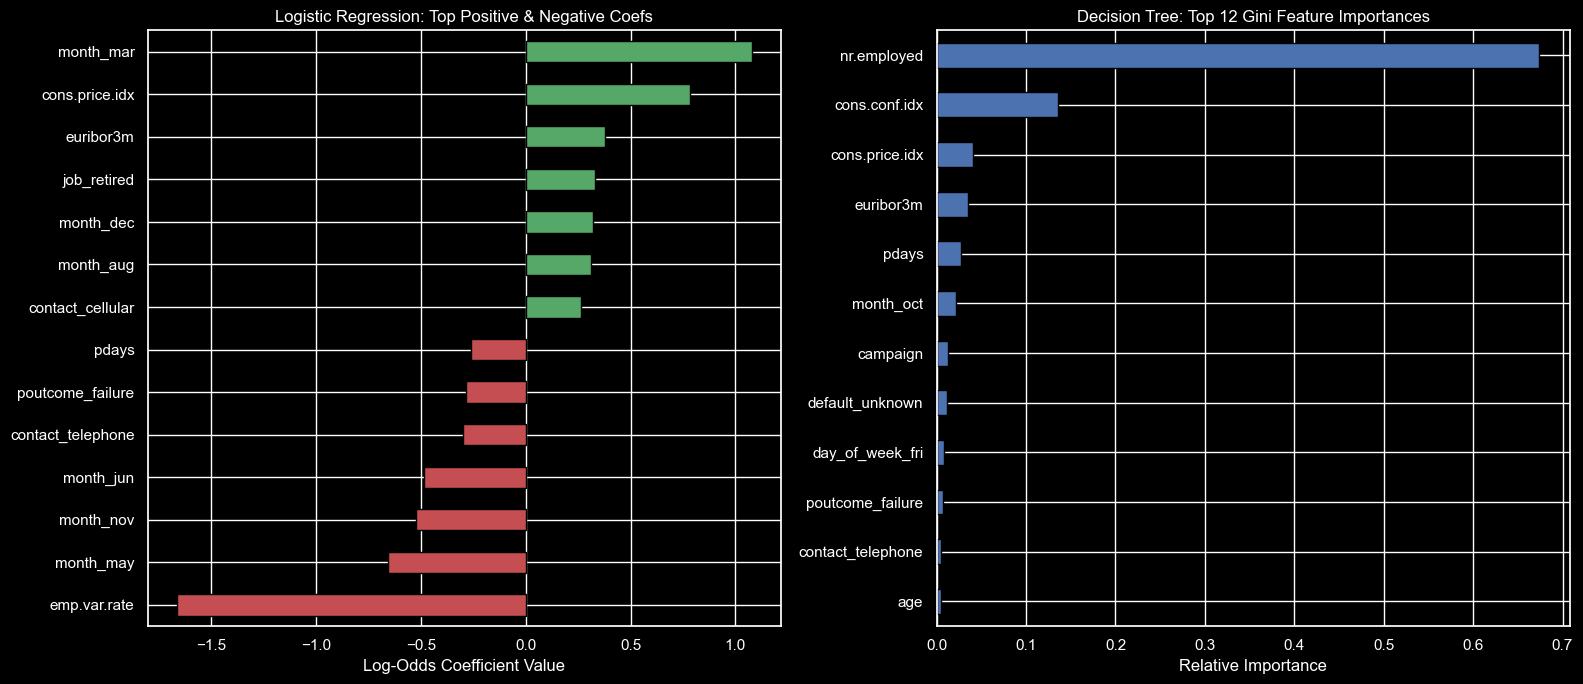

In [70]:
def plot_interpretability(best_models,preproc):
    #Extract feature names after one-hot encoding
    cat_feature_names = (preproc.named_transformers_["cat"].get_feature_names_out(cat_cols).tolist())
    all_feature_names = num_cols + cat_feature_names
    fig,axes = plt.subplots(1,2,figsize=(16,7))
    #Logistic regression coefficients
    best_lr = best_models["Logistic Regression"].named_steps["classifier"]
    lr_coefs = pd.Series(best_lr.coef_[0],index=all_feature_names)
    top_lr = pd.concat([lr_coefs.nlargest(7),lr_coefs.nsmallest(7)]).sort_values()
    top_lr.plot(kind = "barh",ax=axes[0],color=np.where(top_lr > 0,"#55A868","#C44E52"),edgecolor = "black")
    axes[0].set_title("Logistic Regression: Top Positive & Negative Coefs")
    axes[0].set_xlabel("Log-Odds Coefficient Value")
    #Decision tree features
    best_dt = best_models["Decision Tree"].named_steps["classifier"]
    dt_importances = pd.Series(best_dt.feature_importances_,index=all_feature_names).nlargest(12)
    dt_importances.sort_values().plot(kind="barh",ax=axes[1],color="#4C72B0",edgecolor="black")
    axes[1].set_title("Decision Tree: Top 12 Gini Feature Importances")
    axes[1].set_xlabel("Relative Importance")
    plt.tight_layout()
    plt.savefig("images/feature_interpretation.png")
    plt.show()

plot_interpretability(best_estimators,preprocessor)

# Summary
### After hyperparameter tuning Decision tree test accuracy improved a lot. KNN was the fastest model and also the best performing model after tuning.

### Seasonal timing (Mar, Aug & Dec) are in the top possitives. Seasonal Timing (May, Jun & Nov) are most impactful in top negatives. Marketing effectiveness has huge impacts during periods of surging interbank interest rates.

### Employed and retired has more possibility to fall under Yes category

### Previous marketing campaign negatives are still tough to convince.

# Next Steps
### Deploy the tuned Logistic regression / SVM scoring pipeline into the CRM to rank contacts into lift-based targets. Restrict outbound phone outreach to the top 30-40% of scored leads to capture over 75% of all  potential subscribers while cutting call center overhead by more than 50%.

### Automate campaign throttling based on the central bank rate decisions. Accelerate campaigns during the rate cut cycles when term deposits appear more appealing than saving accounts.

### Establish a rule preventing excessive contact attempts as empirical returns decline past 3 attempt without conversation.